In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/HP5CD/Downloads/Global_Music_Streaming_Listener_Preferences.csv")

In [3]:
df.head()

,User_ID,Age,Country,Streaming Platform,Top Genre,Minutes Streamed Per Day,Number of Songs Liked,Most Played Artist,Subscription Type,Listening Time (Morning/Afternoon/Night),Discover Weekly Engagement (%),Repeat Song Rate (%)
0,U1000,34,Japan,Tidal,Reggae,295,138,Adele,Free,Afternoon,47.42,16.74
1,U1001,24,Germany,Deezer,Country,86,388,Ed Sheeran,Premium,Night,12.06,69.25
2,U1002,49,Germany,Deezer,Pop,363,368,Post Malone,Premium,Afternoon,47.19,67.38
3,U1003,55,Australia,YouTube,Reggae,348,349,Dua Lipa,Premium,Morning,31.27,76.51
4,U1004,13,Germany,Amazon Music,Reggae,30,328,Adele,Free,Night,30.68,43.41


In [5]:
#check for missing values
df.isnull().sum()

User_ID                                     0
Age                                         0
Country                                     0
Streaming Platform                          0
Top Genre                                   0
Minutes Streamed Per Day                    0
Number of Songs Liked                       0
Most Played Artist                          0
Subscription Type                           0
Listening Time (Morning/Afternoon/Night)    0
Discover Weekly Engagement (%)              0
Repeat Song Rate (%)                        0
dtype: int64

In [8]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
#check basic statistics
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   User_ID                                   5000 non-null   object 
 1   Age                                       5000 non-null   int64  
 2   Country                                   5000 non-null   object 
 3   Streaming Platform                        5000 non-null   object 
 4   Top Genre                                 5000 non-null   object 
 5   Minutes Streamed Per Day                  5000 non-null   int64  
 6   Number of Songs Liked                     5000 non-null   int64  
 7   Most Played Artist                        5000 non-null   object 
 8   Subscription Type                         5000 non-null   object 
 9   Listening Time (Morning/Afternoon/Night)  5000 non-null   object 
 10  Discover Weekly Engagement (%)      

In [10]:
df.describe()

,Age,Minutes Streamed Per Day,Number of Songs Liked,Discover Weekly Engagement (%),Repeat Song Rate (%)
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,36.664000,309.237200,253.51720,50.296464,42.391060
std,13.763844,172.029822,146.36928,23.171936,21.444121
min,13.000000,10.000000,1.00000,10.020000,5.000000
25%,25.000000,161.000000,126.00000,30.147500,24.195000
50%,37.000000,316.000000,254.00000,50.420000,41.960000
75%,49.000000,457.250000,382.00000,70.337500,60.740000
max,60.000000,600.000000,500.00000,89.990000,79.990000


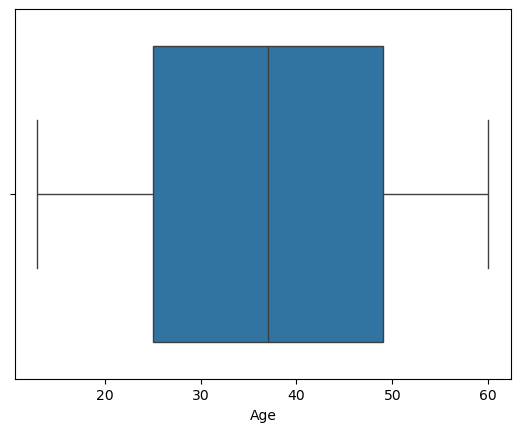

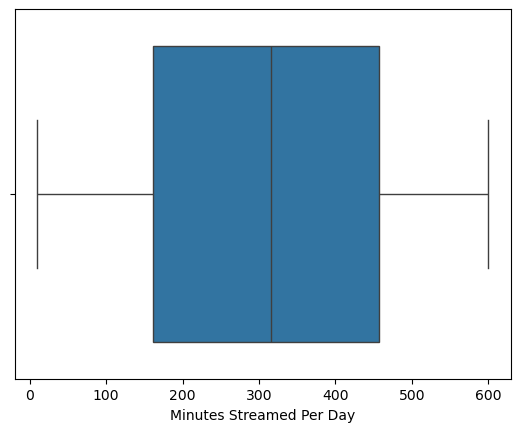

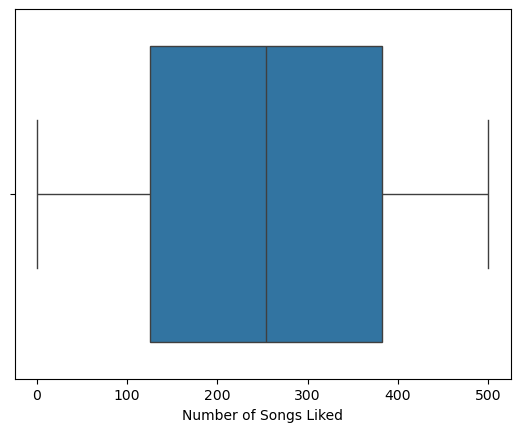

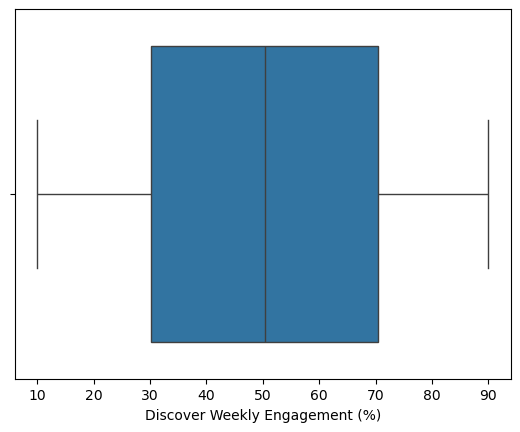

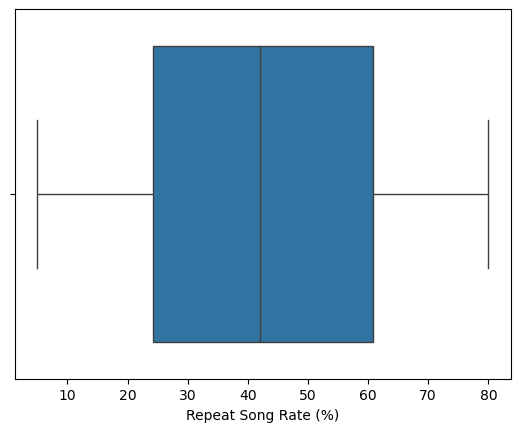

In [11]:
#check for outliers
list_cols_num = ["Age","Minutes Streamed Per Day","Number of Songs Liked","Discover Weekly Engagement (%)","Repeat Song Rate (%)"]
for i in list_cols_num:
    sns.boxplot(data = df, x = i)
    plt.show()

In [12]:
df.columns

Index(['User_ID', 'Age', 'Country', 'Streaming Platform', 'Top Genre',
       'Minutes Streamed Per Day', 'Number of Songs Liked',
       'Most Played Artist', 'Subscription Type',
       'Listening Time (Morning/Afternoon/Night)',
       'Discover Weekly Engagement (%)', 'Repeat Song Rate (%)'],
      dtype='object')

In [17]:
list_numerical_cats = ["Country","Streaming Platform","Top Genre","Most Played Artist","Subscription Type","Listening Time (Morning/Afternoon/Night)"]
for i in list_numerical_cats:
    print(df[i].value_counts())

Country
Australia      526
South Korea    516
UK             516
Brazil         508
Canada         507
France         493
Japan          491
India          490
USA            482
Germany        471
Name: count, dtype: int64
Streaming Platform
Amazon Music    861
Tidal           850
Deezer          844
Spotify         827
YouTube         822
Apple Music     796
Name: count, dtype: int64
Top Genre
Reggae       532
Jazz         532
EDM          528
Rock         516
R&B          495
Metal        491
Hip-Hop      485
Country      484
Classical    475
Pop          462
Name: count, dtype: int64
Most Played Artist
Bad Bunny        528
Adele            519
Post Malone      519
Dua Lipa         502
Ed Sheeran       500
Taylor Swift     496
The Weeknd       490
BTS              488
Drake            481
Billie Eilish    477
Name: count, dtype: int64
Subscription Type
Premium    2526
Free       2474
Name: count, dtype: int64
Listening Time (Morning/Afternoon/Night)
Night        1745
Afternoon    16

In [18]:
df_sp = df["Streaming Platform"].value_counts()

In [19]:
df_sp

Streaming Platform
Amazon Music    861
Tidal           850
Deezer          844
Spotify         827
YouTube         822
Apple Music     796
Name: count, dtype: int64

In [20]:
df_sp.index

Index(['Amazon Music', 'Tidal', 'Deezer', 'Spotify', 'YouTube', 'Apple Music'], dtype='object', name='Streaming Platform')

In [21]:
df_sp.values

array([861, 850, 844, 827, 822, 796])

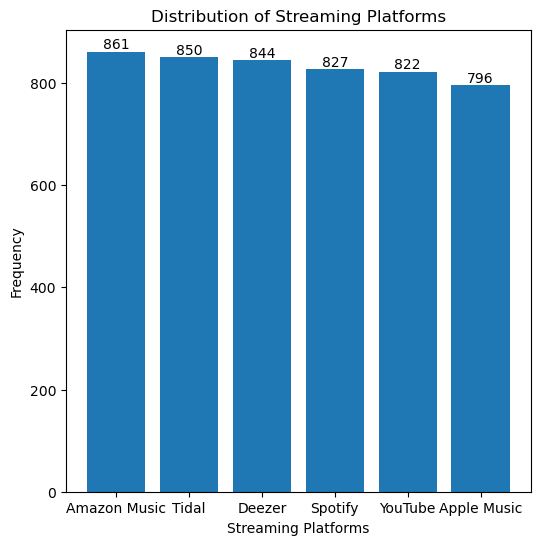

In [57]:
fig, ax = plt.subplots(figsize = (6,6))
bars = ax.bar(df_sp.index, df_sp.values)
ax.set_xlabel("Streaming Platforms")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Streaming Platforms")
ax.bar_label(bars)
plt.show()

In [26]:
#amazon music is the most preferred streaming platform
#apple music is the least preferred streaming platform

In [29]:
#2. How does age impact music preferences?

In [30]:
def age_func (x):
    if x < 18:
        return "<18"
    elif x >= 18 and x <= 30:
        return "18 - 30"
    elif x >= 31 and x <= 45:
        return "31 - 45"
    elif x >= 46 and x <= 60:
        return "46 - 60"
    else: 
        pass

In [78]:
df["Age Group"] = df["Age"].apply(age_func)

In [79]:
df.head()

,User_ID,Age,Country,Streaming Platform,Top Genre,Minutes Streamed Per Day,Number of Songs Liked,Most Played Artist,Subscription Type,Listening Time (Morning/Afternoon/Night),Discover Weekly Engagement (%),Repeat Song Rate (%),age_group,Age Group
0,U1000,34,Japan,Tidal,Reggae,295,138,Adele,Free,Afternoon,47.42,16.74,31 - 45,31 - 45
1,U1001,24,Germany,Deezer,Country,86,388,Ed Sheeran,Premium,Night,12.06,69.25,18 - 30,18 - 30
2,U1002,49,Germany,Deezer,Pop,363,368,Post Malone,Premium,Afternoon,47.19,67.38,46 - 60,46 - 60
3,U1003,55,Australia,YouTube,Reggae,348,349,Dua Lipa,Premium,Morning,31.27,76.51,46 - 60,46 - 60
4,U1004,13,Germany,Amazon Music,Reggae,30,328,Adele,Free,Night,30.68,43.41,<18,<18


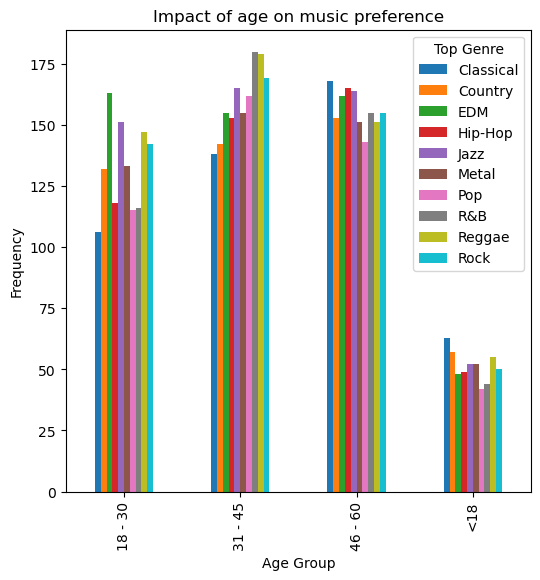

In [35]:
age_music = pd.crosstab(df["age_group"], df["Top Genre"])

fig, ax = plt.subplots(figsize = (6,6))
age_music.plot(kind = "bar", ax = ax)
ax.set_xlabel("Age Group")
ax.set_ylabel("Frequency")
ax.set_title("Impact of age on music preference")
plt.show()

In [37]:
#age impacts music preferences.

In [38]:
#3. What are the most streamed genres and artists?

In [42]:
df.groupby("Most Played Artist") ["Minutes Streamed Per Day"].sum().sort_values(ascending = False)

Most Played Artist
Bad Bunny        163843
Adele            163604
Dua Lipa         159898
Post Malone      157302
Taylor Swift     156525
Ed Sheeran       151754
The Weeknd       151151
BTS              148551
Billie Eilish    147312
Drake            146246
Name: Minutes Streamed Per Day, dtype: int64

In [47]:
df.groupby("Top Genre") ["Minutes Streamed Per Day"].sum().sort_values(ascending = False)

Top Genre
Rock         167367
Jazz         164342
EDM          163846
Reggae       163270
R&B          155949
Hip-Hop      151046
Classical    148971
Metal        148232
Country      142174
Pop          140989
Name: Minutes Streamed Per Day, dtype: int64

In [49]:
df_mpa = df.groupby("Most Played Artist") ["Minutes Streamed Per Day"].sum().sort_values(ascending = False)

In [50]:
df_mpa

Most Played Artist
Bad Bunny        163843
Adele            163604
Dua Lipa         159898
Post Malone      157302
Taylor Swift     156525
Ed Sheeran       151754
The Weeknd       151151
BTS              148551
Billie Eilish    147312
Drake            146246
Name: Minutes Streamed Per Day, dtype: int64

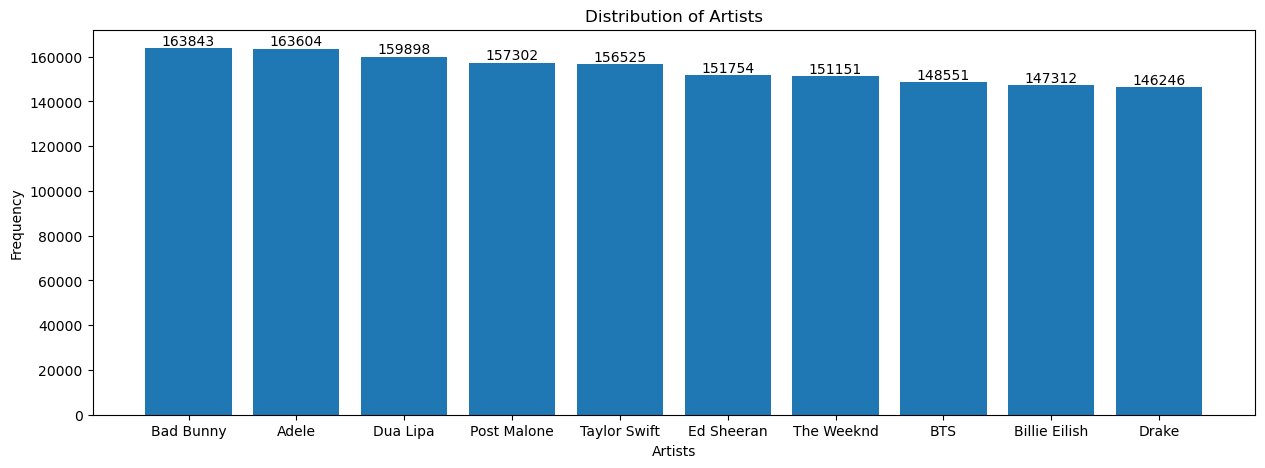

In [71]:
fig, ax = plt.subplots(figsize = (15,5))
bars = ax.bar(df_mpa.index, df_mpa.values)
ax.set_xlabel("Artists")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Artists")
ax.bar_label(bars)
plt.show()

In [55]:
tg = df.groupby("Top Genre") ["Minutes Streamed Per Day"].sum().sort_values(ascending = False)

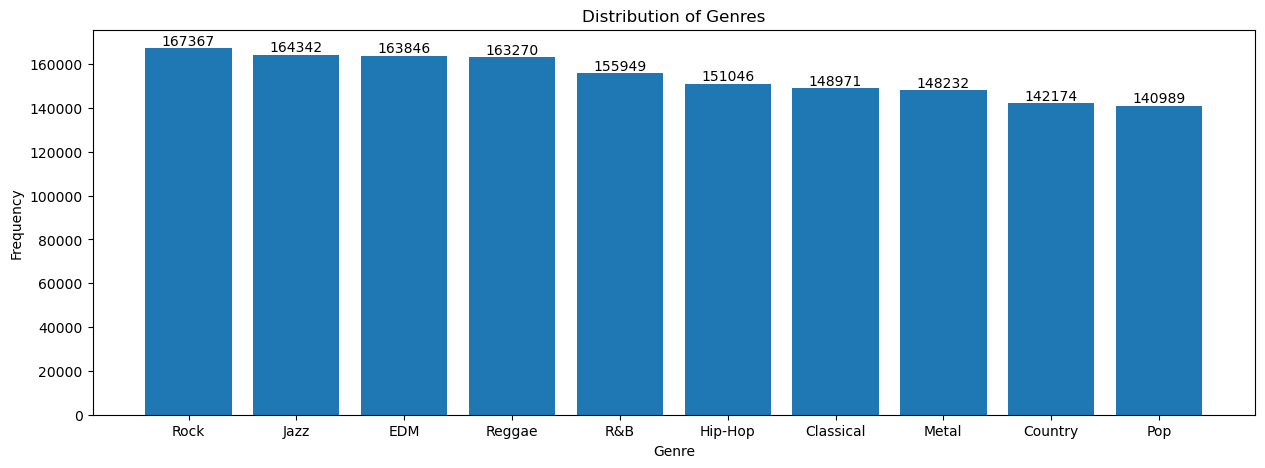

In [72]:
fig, ax = plt.subplots(figsize = (15,5))
bars = ax.bar(tg.index, tg.values)
ax.set_xlabel("Genre")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Genres")
ax.bar_label(bars)
plt.show()

In [56]:
#Most streamed artist is Bad Bunny
#Most streamed genre is Rock

In [64]:
#4. How do free vs. premium users differ in streaming behavior?

In [75]:
df.groupby(["Subscription Type","Streaming Platform"])["Discover Weekly Engagement (%)"].mean()

Subscription Type  Streaming Platform
Free               Amazon Music          49.917269
                   Apple Music           50.038136
                   Deezer                50.426502
                   Spotify               51.343088
                   Tidal                 50.522840
                   YouTube               51.368355
Premium            Amazon Music          49.812654
                   Apple Music           50.370251
                   Deezer                50.034932
                   Spotify               51.630119
                   Tidal                 48.534245
                   YouTube               49.745945
Name: Discover Weekly Engagement (%), dtype: float64

In [76]:
df.groupby(["Subscription Type","Streaming Platform"])["Minutes Streamed Per Day"].mean()

Subscription Type  Streaming Platform
Free               Amazon Music          296.416300
                   Apple Music           307.967254
                   Deezer                313.216749
                   Spotify               299.144608
                   Tidal                 321.488263
                   YouTube               320.882507
Premium            Amazon Music          314.771499
                   Apple Music           310.794486
                   Deezer                301.678082
                   Spotify               298.510740
                   Tidal                 308.266509
                   YouTube               319.466970
Name: Minutes Streamed Per Day, dtype: float64

In [73]:
#There is no significantly difference in between free and premium on the basis of avg mins streamed, avg weekly engagement.

In [74]:
#5. What time of the day do users stream music the most?

In [80]:
df.head()

,User_ID,Age,Country,Streaming Platform,Top Genre,Minutes Streamed Per Day,Number of Songs Liked,Most Played Artist,Subscription Type,Listening Time (Morning/Afternoon/Night),Discover Weekly Engagement (%),Repeat Song Rate (%),age_group,Age Group
0,U1000,34,Japan,Tidal,Reggae,295,138,Adele,Free,Afternoon,47.42,16.74,31 - 45,31 - 45
1,U1001,24,Germany,Deezer,Country,86,388,Ed Sheeran,Premium,Night,12.06,69.25,18 - 30,18 - 30
2,U1002,49,Germany,Deezer,Pop,363,368,Post Malone,Premium,Afternoon,47.19,67.38,46 - 60,46 - 60
3,U1003,55,Australia,YouTube,Reggae,348,349,Dua Lipa,Premium,Morning,31.27,76.51,46 - 60,46 - 60
4,U1004,13,Germany,Amazon Music,Reggae,30,328,Adele,Free,Night,30.68,43.41,<18,<18


In [81]:
 df.groupby("Listening Time (Morning/Afternoon/Night)")["User_ID"].count()

Listening Time (Morning/Afternoon/Night)
Afternoon    1634
Morning      1621
Night        1745
Name: User_ID, dtype: int64

In [82]:
#During night time, users stream music the most.

In [83]:
#6. Are there any regional trends in music streaming preferences?

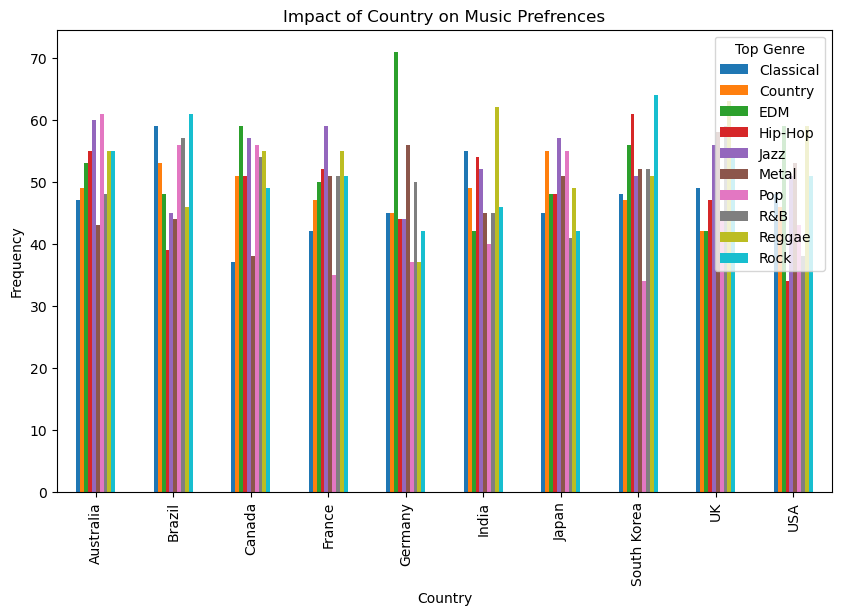

In [86]:
regional_trends = pd.crosstab(df["Country"], df["Top Genre"])
fig, ax = plt.subplots(figsize = (10,6))
regional_trends.plot(kind = "bar", ax = ax)
ax.set_xlabel("Country")
ax.set_ylabel("Frequency")
ax.set_title("Impact of Country on Music Prefrences")
plt.show()

In [87]:
#Yes regional trends affect music preference but not that much significantly.